## Finding Profits in Wells/Sprint 9 Project ##


**Project Description**
This project aims to help OilyGiant Mining Company choose the most profitable
 region for a new oil well. Using the geological data from the three regions, we will use Linear Regression to predict how much oil each well might produce. 


**Steps I Plan to take**
* Import necessary libraries
* Load and explore datasets for all three regions
* Split data in training and validation sets
* Train Linear Regression models and evaluate with RMSE and average prediced reserves
* Calculate break-even volume and compare with regional averages
* Select top 200 wells by predicted reserves and estinate profit
* Use bootstrapping 1000 samples to find average profit, 95% confidence intervals and loss probability
* Compare results and choose the most profitable region 


In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
# Load data directly from TripleTen's provided URLs
df0= pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/datasets/geo_data_0.csv')
df1= pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/datasets/geo_data_1.csv')
df2= pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/datasets/geo_data_2.csv')

print("Data loaded successfully!")
print(f"Region 0: {df0.shape}")
print(f"Region 1: {df1.shape}")
print(f"Region 2: {df2.shape}")


Data loaded successfully!
Region 0: (100000, 5)
Region 1: (100000, 5)
Region 2: (100000, 5)


In [3]:
# Checking basic data structure
display((df0.info()),(df1.info()), df2.info())
df0.sample(4), df1.sample(4), df2.sample(4)
display(df0.describe(), df1.describe(), df2.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null 

None

None

None

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.500419,0.250143,2.502647,92.500000
std,0.871832,0.504433,3.248248,44.288691
min,-1.408605,-0.848218,-12.088328,0.000000
25%,-0.072580,-0.200881,0.287748,56.497507
50%,0.502360,0.250252,2.515969,91.849972
75%,1.073581,0.700646,4.715088,128.564089
max,2.362331,1.343769,16.003790,185.364347


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.141296,-4.796579,2.494541,68.825000
std,8.965932,5.119872,1.703572,45.944423
min,-31.609576,-26.358598,-0.018144,0.000000
25%,-6.298551,-8.267985,1.000021,26.953261
50%,1.153055,-4.813172,2.011479,57.085625
75%,8.621015,-1.332816,3.999904,107.813044
max,29.421755,18.734063,5.019721,137.945408


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.002023,-0.002081,2.495128,95.000000
std,1.732045,1.730417,3.473445,44.749921
min,-8.760004,-7.084020,-11.970335,0.000000
25%,-1.162288,-1.174820,0.130359,59.450441
50%,0.009424,-0.009482,2.484236,94.925613
75%,1.158535,1.163678,4.858794,130.595027
max,7.238262,7.844801,16.739402,190.029838


In [4]:
# Checking for any Duplicated or Missing Values
display(df0.isna().sum(), df2.isna().sum(), df2.isna().sum())
display(df0.duplicated().sum(),df1.duplicated().sum(),df2.duplicated().sum())

id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

0

0

0

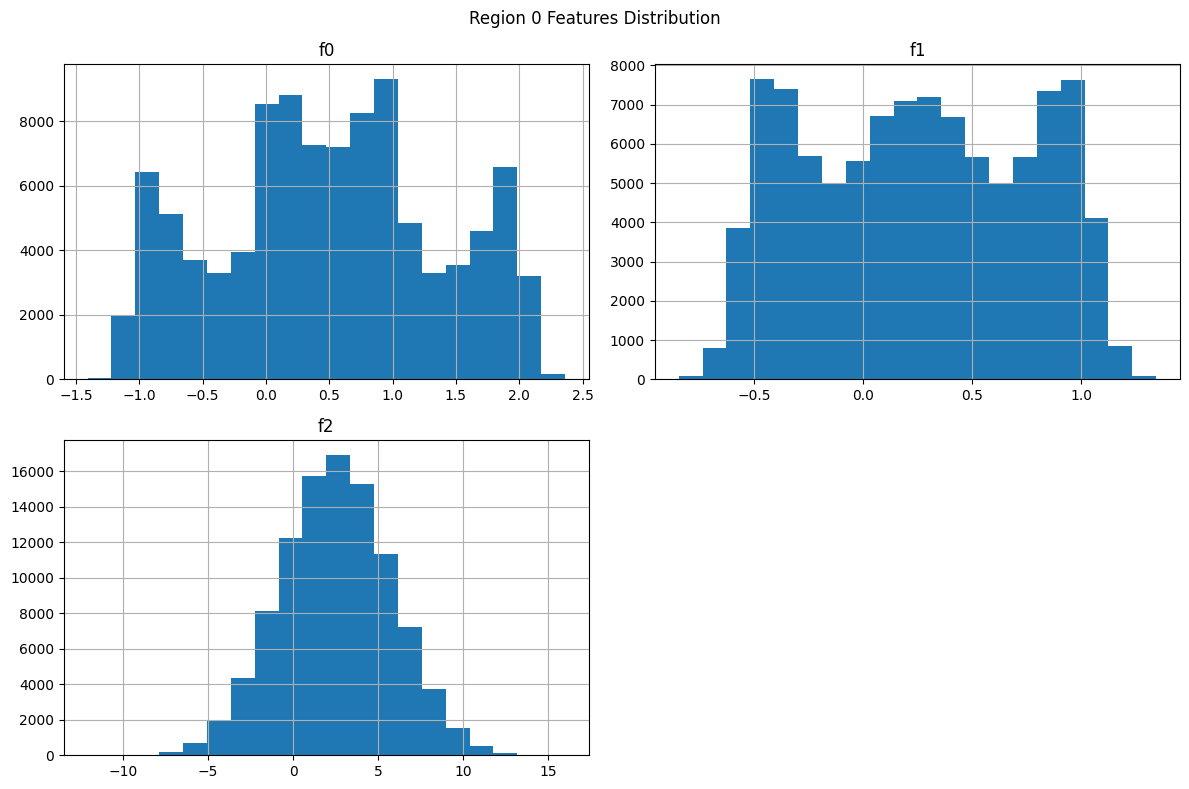

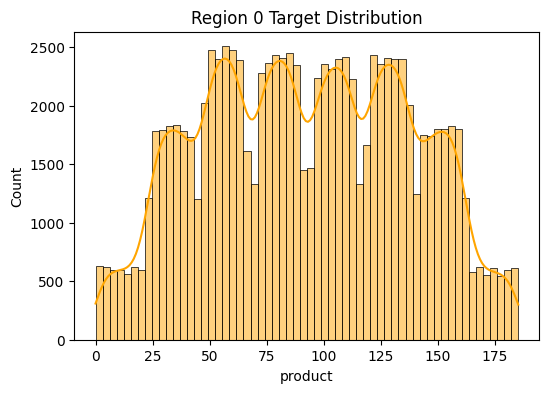

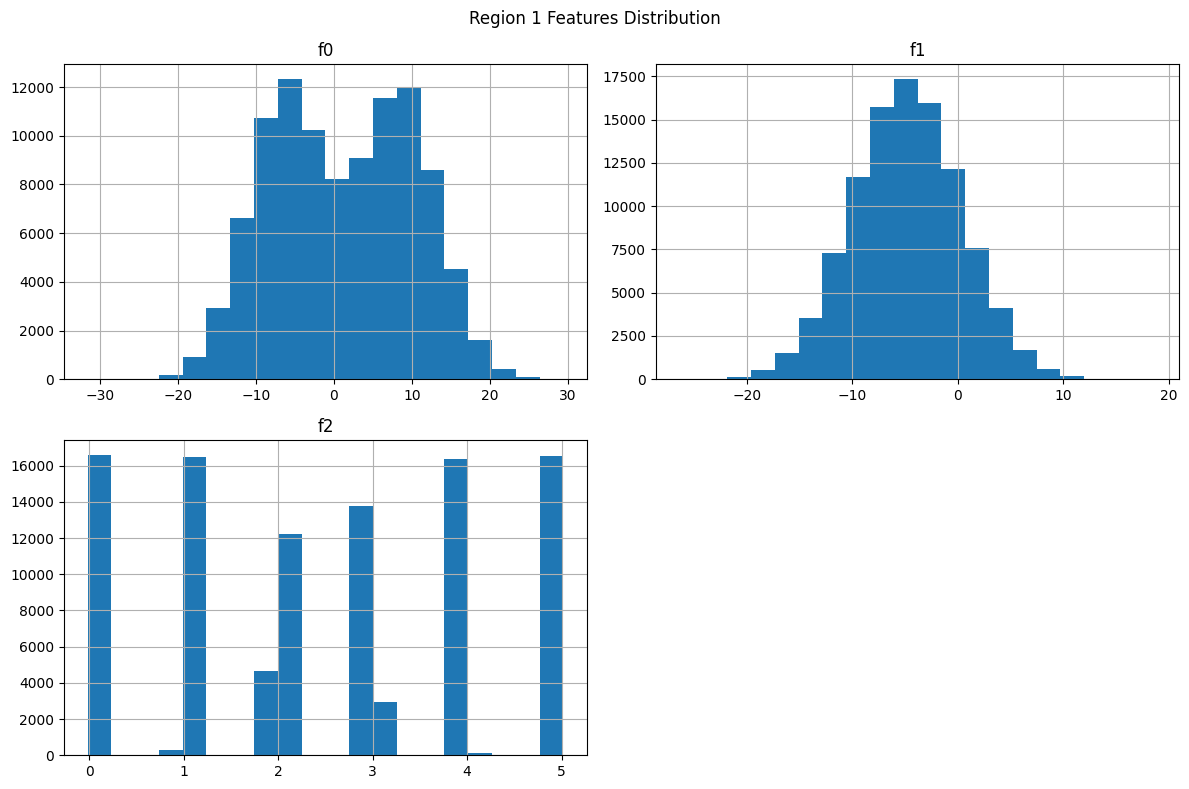

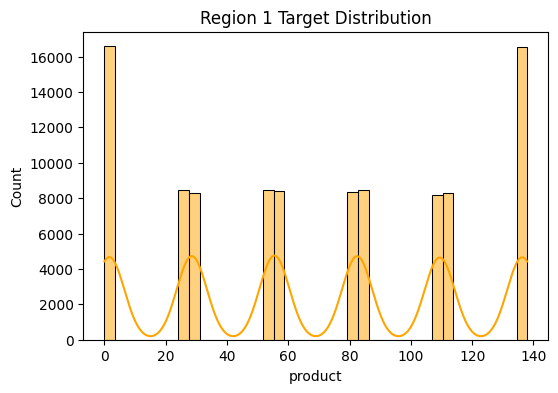

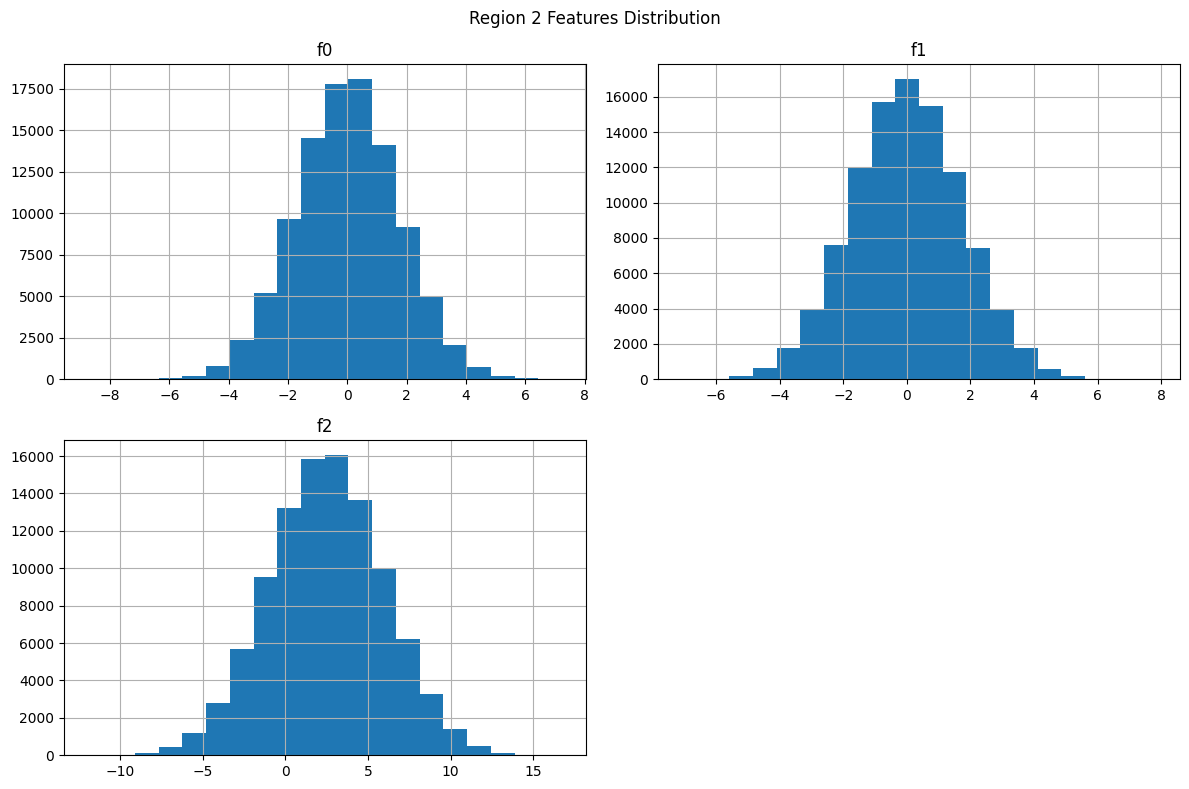

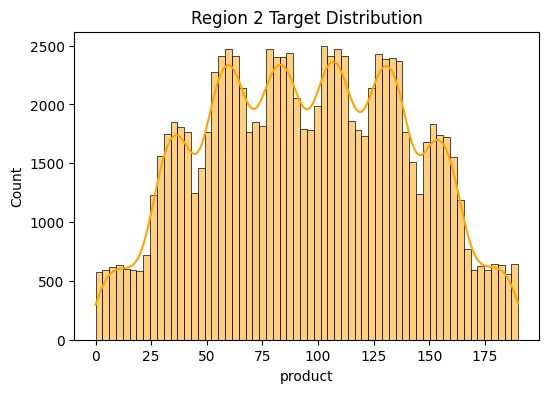

In [5]:
# Plot Distribution of Features and Target
def distribution_plots(df, region_name):
    # Plot features 
    df.drop(['id', 'product'], axis=1).hist(figsize=(12, 8), bins=20)
    plt.suptitle(f'{region_name} Features Distribution')
    plt.tight_layout()
    plt.show()

    # Plot target 
    plt.figure(figsize=(6, 4))
    sns.histplot(df['product'], kde=True, color='orange')
    plt.title(f'{region_name} Target Distribution')
    plt.show()

distribution_plots(df0, "Region 0")
distribution_plots(df1, "Region 1")
distribution_plots(df2, "Region 2")



In [6]:
df1['f2'].describe()
# Looks normal 
display(df1['f2'].sample(10))

5202     2.001850
58241   -0.009972
6319     4.002992
68929    0.994731
84439    3.998693
77461    2.999574
51740    0.994129
93407    3.990834
43271    1.997398
22788    1.991492
Name: f2, dtype: float64

**Conclusion** 

* Displaying distributions help us evaluate the data, find outliers, and helped us with the features of the graphs and their importance.
So far everything looks normal, df1['f2'] was looking unusual but it looks like the values are floats that are close to whole numbers. The distributions on all the graphs visualy looks normal. No extreme like outliers or skewed graphs. 


In [7]:

def train_and_test(df, region_name, random_state=12345):
    features= df.drop(['product', 'id'], axis=1) 
    target= df['product']
    
    # Train-test split
    features_train, features_valid, target_train, target_valid = train_test_split(
        features, target, test_size=0.25, random_state=random_state
    )

    # Train model
    model= LinearRegression()
    model.fit(features_train, target_train)

    # Predict
    prediction = model.predict(features_valid)


    # RMSE
    rmse= np.sqrt(mean_squared_error(target_valid, prediction))
    print(region_name)
    print(f"RMSE: {rmse:.2f}")
    print(f"Average Predicted Volume: {prediction.mean():.2f}")
    print(f"Average Actual Volume: {target_valid.mean():.2f}")
    print()

    return {
        "model": model,
        "features_valid": features_valid,
        "target_valid": target_valid,
        "predictions": prediction,
        "rmse": rmse,
        "avg_pred": prediction.mean(),
        "avg_actual": target_valid.mean()
    }

# Run for all regions
train_test_df0 = train_and_test(df0, "Region 0")
train_test_df1 = train_and_test(df1, "Region 1")
train_test_df2 = train_and_test(df2, "Region 2")

Region 0
RMSE: 37.58
Average Predicted Volume: 92.59
Average Actual Volume: 92.08

Region 1
RMSE: 0.89
Average Predicted Volume: 68.73
Average Actual Volume: 68.72

Region 2
RMSE: 40.03
Average Predicted Volume: 94.97
Average Actual Volume: 94.88



**Conclusions** 

* Region 1 shows the best performance with a very low RMSE of 0.89, showing high accurate predictions. The average predicted and actual volumes are almost identical, which means the model captures the data well for this region.

* Region 0 has a moderate RMSE of 37.58, with predicted and actual averages close but less accurate than Region 1. This suggests the model performs reasonably well but with more error.

* Region 2 has the highest RMSE at 40.03, showing the least accurate predictions among the three regions. Although the predicted and actual averages are similar, the larger RMSE garners more errors.

Overall, the model fits Region 1 data best, followed by Region 0, with Region 2 being the most challenging for prediction.

In [8]:
def prepare_profit_data(train_test_results,
                        region_name,
                        budget=100000000,
                        number_wells_selected=200,
                        sample_wells=500,
                        revenue_per_unit=4500,
                        random_state=12345):
    
    features_valid= train_test_results["features_valid"]
    target_valid = train_test_results["target_valid"]
    model= train_test_results["model"]

    # Calculate break-even volume
    min_volume= (budget / number_wells_selected) / revenue_per_unit

    # Sample wells
    sample500 = features_valid.sample(n=sample_wells, random_state=random_state)
    target_sample = target_valid.loc[sample500.index]
    predicted_sample= model.predict(sample500)

    sample500_results = pd.DataFrame({
        'predicted': predicted_sample,
        'actual': target_sample.values
    }).sort_values(by='predicted', ascending=False)
    
    print(region_name)
    print(f"Minimum volume for break-even: {min_volume:.2f} barrels")
    print(f"Average actual volume in region: {train_test_results['avg_actual']:.2f} barrels")

    if train_test_results["avg_actual"] > min_volume:
        print("On average, wells produce more than break-even. Good profit potential.")
    else:
        print("On average, wells don’t produce enough to break even.")
    print()

    return {
        "sample500_results": sample500_results,
        "min_volume": min_volume
    }

# Run for all regions
profit_data_0 = prepare_profit_data(train_test_df0, "Region 0")
profit_data_1 = prepare_profit_data(train_test_df1, "Region 1")
profit_data_2 = prepare_profit_data(train_test_df2, "Region 2")


Region 0
Minimum volume for break-even: 111.11 barrels
Average actual volume in region: 92.08 barrels
On average, wells don’t produce enough to break even.

Region 1
Minimum volume for break-even: 111.11 barrels
Average actual volume in region: 68.72 barrels
On average, wells don’t produce enough to break even.

Region 2
Minimum volume for break-even: 111.11 barrels
Average actual volume in region: 94.88 barrels
On average, wells don’t produce enough to break even.



**Conclusions**

* I calculated the break-even volume per well at about 111 barrels based on the budget and revenue. This is the minimum amount of oil each well needs to produce to avoid losing money.
* Looking at the average actual oil volumes for each region, none of them quite reach this break-even level. Region 1 has the lowest average, meaning it likely has less oil and lower profit potential despite having the best model fit earlier. Regions 0 and 2 have similar average volumes, a bit higher than Region 1, but still under the break-even point.
* So, even though Region 1’s predictions looked most accurate, its wells produce the least oil on average. Regions 0 and 2 produce more oil, but still not enough on average to break even.

In [9]:
# Calculate total profit
def calculate_profit(sample500_results,
                     region_name,
                     number_wells_selected=200,
                     revenue_per_unit=4500,
                     budget=100000000):
    

    top200_wells= sample500_results.head(number_wells_selected)
    print(region_name)
    print(top200_wells.head(5), top200_wells.shape)
    
    total_actual_volume= top200_wells['actual'].sum()
    profit= (total_actual_volume * revenue_per_unit) - budget
    
    print(f"Total Actual Volume of Top {number_wells_selected} wells: {total_actual_volume:,.2f} barrels")
    print(f"Profit: ${profit:,.2f}")
    print()
    
    return profit

profit_0 = calculate_profit(profit_data_0["sample500_results"], "Region 0")
profit_1 = calculate_profit(profit_data_1["sample500_results"], "Region 1")
profit_2 = calculate_profit(profit_data_2["sample500_results"], "Region 2")

Region 0
      predicted      actual
479  154.489037  146.190600
211  152.721019  158.082667
377  152.707009  147.574276
202  151.488439  146.474576
103  151.020922  141.244360 (200, 2)
Total Actual Volume of Top 200 wells: 23,731.26 barrels
Profit: $6,790,688.58

Region 1
      predicted      actual
219  139.560938  137.945408
174  139.424526  137.945408
141  139.007124  137.945408
122  138.979963  137.945408
58   138.888525  137.945408 (200, 2)
Total Actual Volume of Top 200 wells: 23,954.40 barrels
Profit: $7,794,798.84

Region 2
      predicted      actual
386  153.650598  150.052277
309  145.615286  181.850425
394  144.978488  117.105262
291  143.454112  118.938576
208  142.654213  127.962789 (200, 2)
Total Actual Volume of Top 200 wells: 23,199.98 barrels
Profit: $4,399,901.43



**Conclusions** 
* Region 1 has the highest profit, making it the most valuable area for oil well development so far.
* Region 0 follows closely behind, just shy of a million less in profit.
* Region 2 has the lowest profit among the three. Even though Regions 0 and 1 have similar actual volumes, Region 1’s higher profit suggests better well quality and efficiency in extraction. This supports what we saw earlier with the model predictions and RMSE values.

Overall, Region 1 offers the best balance of volume and predictability. Based on predicted reserves and calculated profits, Region 1 appears to be the best choice for development.

In [10]:
def bootstrap_profit(train_test_results,
                     region_name,
                     number_wells_selected=200,
                     revenue_per_unit=4500,
                     budget=100000000,
                     sample_wells=500,
                     n_bootstrap=1000,
                     random_state=12345):
    
    rng= np.random.RandomState(random_state)
    profits = []

    features_valid= train_test_results["features_valid"]
    target_valid = train_test_results["target_valid"]
    predictions = train_test_results["predictions"]

       # DataFrame of full validation set 
    valid_df = features_valid.copy()
    valid_df['actual']= target_valid
    valid_df['predicted']= predictions

    for i in range(n_bootstrap):
        bootstrap_sample= valid_df.sample(n=sample_wells, replace=True, random_state=rng)
        top_wells= bootstrap_sample.nlargest(number_wells_selected, 'predicted')
        total_actual_volume = top_wells['actual'].sum()
        profit = (total_actual_volume * revenue_per_unit) - budget
        profits.append(profit)
    
    avg_profit= np.mean(profits)
    ci_lower = np.quantile(profits, 0.025)
    ci_upper= np.quantile(profits, 0.975)
    risk_of_loss= (np.array(profits) < 0).mean() * 100

    print(f"{region_name}:")
    print(f"Average Profit (Bootstrapped {n_bootstrap} times): ${avg_profit:,.2f}")
    print(f"95% CI: (${ci_lower:,.2f}, ${ci_upper:,.2f})")
    print(f"Risk of Loss: {risk_of_loss:.2f}%\n")

    return avg_profit, ci_lower, ci_upper, risk_of_loss

# Run for each region
bootstrap_profit(train_test_df0, "Region 0")
bootstrap_profit(train_test_df1, "Region 1")
bootstrap_profit(train_test_df2, "Region 2")


Region 0:
Average Profit (Bootstrapped 1000 times): $3,961,649.85
95% CI: ($-1,112,155.46, $9,097,669.42)
Risk of Loss: 6.90%

Region 1:
Average Profit (Bootstrapped 1000 times): $4,560,451.06
95% CI: ($338,205.09, $8,522,894.54)
Risk of Loss: 1.50%

Region 2:
Average Profit (Bootstrapped 1000 times): $4,044,038.67
95% CI: ($-1,633,504.13, $9,503,595.75)
Risk of Loss: 7.60%



(4044038.665683568, -1633504.1339559986, 9503595.749237997, 7.6)

**Conclusions**
* Based on the bootstrapping results over 1,000 iterations, Region 1 stands out as the best choice. It has the highest average profit at approximately $4.56 million and the lowest risk of loss at 1.5%, making it the safest bet among the three.
* Region 0 follows, with slightly lower average profits 3.96M and a moderate risk of 6.9%
* Region 2 ranks last, showing near the lowest average profit 4.04M and the highest risk of loss at 7.6%.
* Looking at the confience intervals, both Region 0 and Region 2 have negative values
* Region 1 has a mire stable and predictable profit range compared to Regions 0 and Region 2. 
  
Overall, Region 1 offers the best balance of profitability and risk, making it the most suitable option for OilyGiant Mining Company.


## Process ## 

* The data was first split as a set ratio of 75:25, training and validation set.
* Trained a Linear Regression model to predict oil reserves
* Evaluated the models performance using the RMSE and average predicted volumes
* Calculated the break even volume per well and compared it with the acutual voumes
* Selected the top wells by predicted volume to estimate potential profit.
* Applied bootsrapping to estimate profit, calculate 95% confidence intervals, and measure risk of losses

## Results ##
* Region 1 had the most accurate predictions by far, with way lower errors than the others even though its average actual volume is the lowest, about 69 barrels.
* Regions 0 and 2 had similar volumes around 92 to 95 barrels, but their predictions were a lot less reliable.
* None of the regions quite hit the break-even volume of 111 barrels on average, so wells generally don’t produce enough to cover costs.
* When we look at the profits from the top 200 wells, Region 1 is the clear winner with nearly 7.8 million, then Region 0 with about 6.8 million, and Region 2 is behind at $4.4 million.
* After running the bootstrapping, which checks profit variability:
    * Region 1 has the highest average profit and the tightest range of results, plus the lowest chance of losing money (only about 1.5%).
    * Regions 0 and 2 have more ups and downs, with a higher risk of losses around 7%.

## Final Thoughts ##
* While none of the other 2 regions meet the break-even point, **Region 1** is the best option. It’s the safest pick with solid profits and less risk. Regions 0 and 2 are riskier bets with less predictable returns. 